# Tarea 2: Procesamiento de Texto con Python
### Integrantes:
* Sebastian Vargas
* Sebastian Leon
* Rodrigo Ramirez

**Asignatura:** Taller de Python para Ciencia de Datos

## Tabla de Contenidos

*  [Introduccion](#0)
*  [Limpieza de datos](#1)
*  [Graficos](#2)
*  [Conclusion](#3)

# Introduccion <a id="0"></a>

Previo a todo el trabajo hay que instalar 3 librerias para el desarrollo de la tarea:

* NumPy ayuda a gestionar los cálculos y la lógica numérica de fondo.

* Pandas toma esos datos, los organiza en tablas y los limpia para que sean legibles.

* Matplotlib toma los datos ya limpios de Pandas y los traduce en imágenes que cualquier persona puede entender a simple vista.

In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ahora importamos las bibliotecas

In [2]:
import numpy as np  # util para computación científica en Python
import pandas as pd # biblioteca que contienen la estructura de datos de uso principal
import matplotlib.pyplot as plt
import os

# Introduccion <a id="0"></a>

cargar archivo

In [3]:
# --- 1. CONFIGURACIÓN DE RUTAS ---
# '..' significa subir un nivel (salir de la carpeta 'notebooks')
path_entrada = os.path.join('..', 'data', 'raw', 'global_freelancers_raw.csv')
path_salida = os.path.join('..','data', 'processed', 'global_freelancers_processed.csv')

In [4]:
# --- 2. CARGA DE DATOS ---
df = pd.read_csv(path_entrada)
print("Base cargada correctamente desde la carpeta raw.")

Base cargada correctamente desde la carpeta raw.


In [5]:
# Limpiar nombres de columnas (quitar espacios invisibles)
df.columns = df.columns.str.strip()

In [6]:
# Estandarizar Género
gender_map = {
    'f': 'Female', 'female': 'Female', 'fem': 'Female',
    'm': 'Male', 'male': 'Male', 'masc': 'Male'
}
df['gender'] = df['gender'].astype(str).str.lower().str.strip().map(gender_map).fillna('Other')

In [7]:
# Limpiar Hourly Rate (quitar $ y USD y convertir a número)
df['hourly_rate (USD)'] = (df['hourly_rate (USD)']
                           .astype(str)
                           .str.replace(r'[\$,USD]', '', regex=True)
                           .replace('nan', np.nan)
                           .astype(float))

In [8]:
# Limpiar Satisfacción (quitar % y convertir a número)
df['client_satisfaction'] = (df['client_satisfaction']
                             .astype(str)
                             .str.replace('%', '')
                             .replace('nan', np.nan)
                             .astype(float))

In [9]:
# Usamos la mediana para las columnas numéricas
cols_num = ['age', 'years_of_experience', 'hourly_rate (USD)', 'rating', 'client_satisfaction']
for col in cols_num:
    df[col] = df[col].fillna(df[col].median())

In [24]:
# 1. Diccionario con llaves en minúsculas
active_map = {
    '1': 'yes', 
    'true': 'yes', 
    'yes': 'yes', 
    'y': 'yes',
    '0': 'no', 
    'false': 'no', 
    'n': 'no', 
    'no': 'no',
    'nan': 'no',
}

# 2. Paso clave: Convertir a string pero manejar el 'nan'
# Primero limpiamos y pasamos a minúsculas
df['is_active'] = df['is_active'].astype(str).str.lower().str.strip()

# 3. Aplicamos el mapa
df['is_active'] = df['is_active'].map(active_map)

# 4. nan se convierte en "no"
df['is_active'] = df['is_active'].fillna('no')

In [25]:
# --- 5. GUARDADO ---
# Esto guardará el archivo en la carpeta 'processed'
df.to_csv(path_salida, index=False)

print(f"Proceso terminado. Archivo guardado en: {path_salida}")

Proceso terminado. Archivo guardado en: ..\data\processed\global_freelancers_processed.csv


In [26]:
# Carga el archivo que acabas de guardar para estar seguro
df_limpio = pd.read_csv(path_salida)

# Comprobar nulos
print(df_limpio.isnull().sum())

freelancer_ID          0
name                   0
gender                 0
age                    0
country                0
language               0
primary_skill          0
years_of_experience    0
hourly_rate (USD)      0
rating                 0
is_active              0
client_satisfaction    0
dtype: int64


In [30]:
print("Valores únicos en Gender:", df_limpio['gender'].unique())
print("Valores únicos en Active:", df_limpio['is_active'].unique())

Valores únicos en Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Valores únicos en Active: <StringArray>
['no', 'yes']
Length: 2, dtype: str


# Graficos <a id="2"></a>

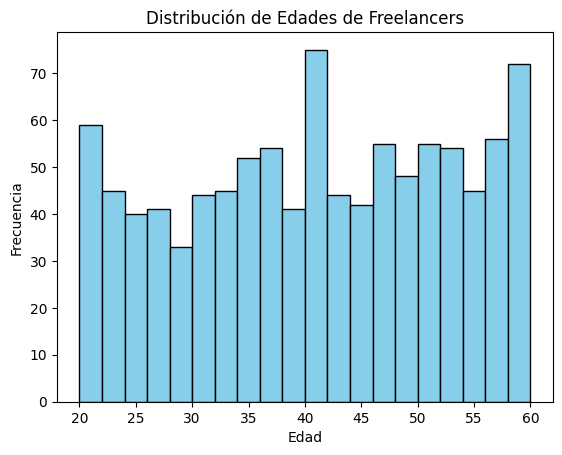

In [43]:
# Gráfico
df_limpio['age'].plot(kind='hist', bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de Edades de Freelancers')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

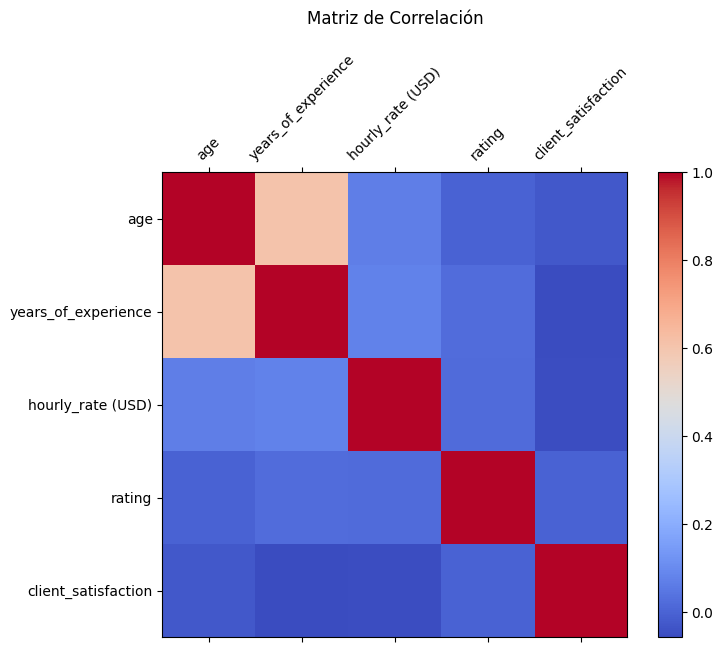

In [44]:
# Seleccionar solo columnas numéricas
corr = df_limpio[['age', 'years_of_experience', 'hourly_rate (USD)', 'rating', 'client_satisfaction']].corr()

# Crear el gráfico
plt.figure(figsize=(8, 6))
plt.matshow(corr, cmap='coolwarm', fignum=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title('Matriz de Correlación', pad=20)
plt.show()

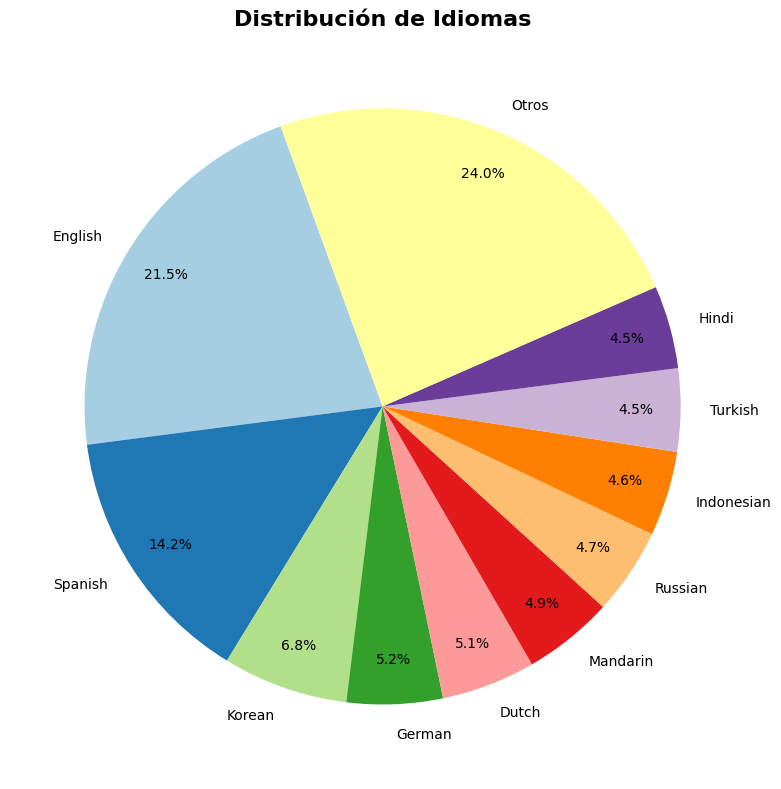

In [94]:
# 2. Contar frecuencias de idiomas
lang_counts = df['language'].value_counts()

# 3. Separar el Top 10 y agrupar el resto en "Otros"
top_10 = lang_counts.head(10)
otros_valor = lang_counts.iloc[10:].sum()
otros_series = pd.Series({'Otros': otros_valor})

# 4. Unir ambos para tener el set de datos final
datos_finales = pd.concat([top_10, otros_series])

# ... (tus pasos 2, 3 y 4 se mantienen igual) ...

# 5. Crear el gráfico de torta
plt.figure(figsize=(8, 8)) # Un poco más grande ayuda a que los nombres quepan

# Definir colores
colores = plt.cm.Paired(range(len(datos_finales)))

# AGREGAMOS 'labels' para que aparezcan los nombres
datos_finales.plot(
    kind='pie', 
    labels=datos_finales.index, # <--- ESTA ES LA SOLUCIÓN
    autopct='%1.1f%%', 
    startangle=110, 
    colors=colores,
    pctdistance=0.85,  # Aleja el % del centro para que no choque con el nombre
    labeldistance=1.1  # Aleja un poco el nombre del idioma del círculo
) 

# 6. Estética profesional
plt.title('Distribución de Idiomas', fontsize=16, fontweight='bold')
plt.ylabel('') # Esto quita el texto "None" o "count" que sale al costado

plt.tight_layout()
plt.show()